In [28]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

In [26]:
def calculate_emissions(sum_dist, em_factor, unit_to_km=0.5):
    km_dist = sum_dist * unit_to_km # converts grid units to km
    return km_dist * em_factor

emissions_diesel = calculate_emissions(sum_dist, 0.149, unit_to_km=0.5)
emissions_ev = calculate_emissions(sum_dist, 0.05703, unit_to_km=0.5)
print("Emissions for a diesel van:", emissions_diesel, "kg CO2")
print("Emissions for an electric van:", emissions_ev, "kg CO2")

Emissions for a diesel van: 5.8613333472768545 kg CO2
Emissions for an electric van: 2.243435173122141 kg CO2


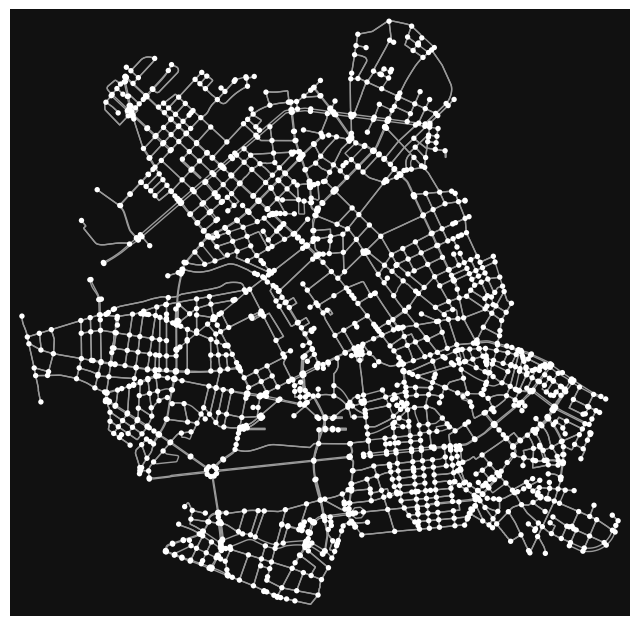

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [9]:
import osmnx as ox
import networkx as nx 

G = ox.graph_from_place("Mitte, Berlin, Germany", network_type="drive")
ox.plot_graph(G)

In [16]:
def assign_emissions(G, em_factor = 0.149):
    for u, v, k, data in G.edges(keys = True, data = True): # u, v=start+end nodes of road segment, k=edge key, data=dictionary edge attributes
        km = data["length"]/1000 # converts m to km
        data["emission"] = km * em_factor

assign_emissions(G)

def travel_time(G):
    for u, v, k, data in G.edges(keys = True, data = True):
        speed = data.get("maxspeed", 30) # finds assigned speed, if there is not one 30 km/h default

        if isinstance(speed, list):
            speed = speed[0]
        try:
            speed = float(speed)
        except:
            speed = 30 

        speed_mps = speed * 1000/3600 # converts km/h to m/s
        data["travel_time"] = data["length"]/speed_mps # travel time in s

travel_time(G)
            
#sample_edge = list(G.edges(data=True))[0][2]
#print(sample_edge["length"], "meters")
#print(sample_edge["emission"], "kg CO₂")
#print(sample_edge["travel_time"], "seconds")
        

In [17]:
import random

nodes = list(G.nodes)
delivery_n = random.sample(nodes, 6)

depot = delivery_n[0]
deliveries = delivery_n[1:]

print("Depot node:", depot)
print("Delivery nodes:", deliveries)

Depot node: 24985997
Delivery nodes: [29194693, 21487284, 320943656, 9515535055, 9569647617]


Carbon-optimized route length: 50 segments
Time-optimized route length: 50 segments


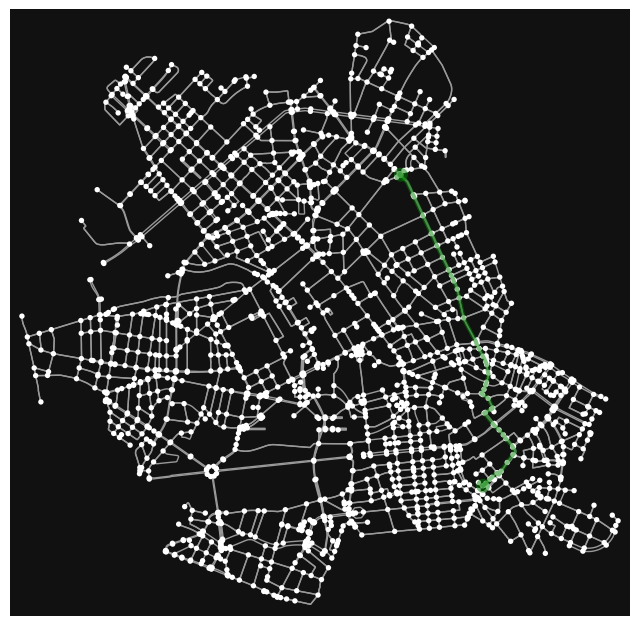

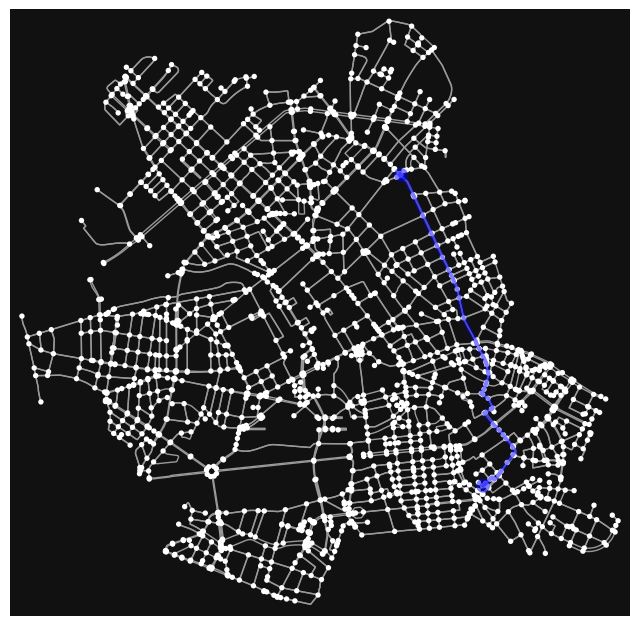

Total CO₂ (kg) for emission saving route: 0.7279109434942648
Total time (s) for emission saving route: 458.08145199792375
Total CO₂ (kg) for time saving route: 0.7291323911246126
Total time (s) for time saving route: 456.51891329299394


In [20]:
first_delivery = deliveries[0]

route_emission = nx.shortest_path(G, depot, first_delivery, weight="emission")
route_time = nx.shortest_path(G, depot, first_delivery, weight="travel_time")

print("Carbon-optimized route length:", len(route_emission), "segments")
print("Time-optimized route length:", len(route_time), "segments")

ox.plot_graph_route(G, route_emission, route_color='green', route_linewidth=3)
ox.plot_graph_route(G, route_time, route_color='blue', route_linewidth=3)

def get_total(G, route, weight):
    return sum(G[u][v][k].get(weight, 0) for u, v, k in zip(route[:-1], route[1:], [0]*len(route)))

print("Total CO₂ (kg) for emission saving route:", get_total(G, route_emission, 'emission'))
print("Total time (s) for emission saving route:", get_total(G, route_emission, 'travel_time'))
print("Total CO₂ (kg) for time saving route:", get_total(G, route_time, 'emission'))
print("Total time (s) for time saving route:", get_total(G, route_time, 'travel_time'))

In [30]:
import random

nodes = list(G.nodes)
delivery_n = random.sample(nodes, 6)
depot = delivery_n[0]
deliveries = delivery_n[1:]

map_p = [depot] + deliveries
n = len(map_p)

import networkx as nx 



[0, 0, 0, 0, 0, 0]
